### Configuração e Importações

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv

# Importa a conexão do seu módulo estruturado
from banco import conectar

# Carrega as variáveis de ambiente do seu arquivo .env
load_dotenv()

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### Configuração e Importações
Como a documentação para criação do projeto exige que a camada Gold agregada seja criada no banco de dados como tabela e como VIEW, executamos esse script direto via Python para garantir a automação do pipeline:

In [3]:
conexao = conectar()
cursor = conexao.cursor()

try:
    # 1. Criação da Tabela Gold de Resumo por Órgão.

    cursor.execute("DROP TABLE IF EXISTS gold_resumo_orgao CASCADE;")
    cursor.execute(
        """
        CREATE TABLE gold_resumo_orgao (
            nome_orgao_superior VARCHAR(255) PRIMARY KEY,
            total_viagens INT,
            custo_total_diarias DECIMAL(12,2),
            custo_total_passagens DECIMAL(12,2),
            custo_total_geral DECIMAL(12,2),
            duracao_media_dias DECIMAL(5,2)
        );
    """
    )

    # Carga dos dados na tabela usando JOIN e GROUP BY
    cursor.execute(
        """
        INSERT INTO gold_resumo_orgao
        SELECT 
            nome_orgao_superior,
            COUNT(id_viagem) AS total_viagens,
            SUM(valor_diarias) AS custo_total_diarias,
            SUM(valor_passagens) AS custo_total_passagens,
            SUM(valor_total) AS custo_total_geral,
            AVG(duracao_dias) AS duracao_media_dias
        FROM silver_viagem
        GROUP BY nome_orgao_superior;
    """
    )

    # 2. Criação da VIEW Analítica integrada
    cursor.execute(
        """
        CREATE OR REPLACE VIEW v_gold_detalhe_viagens AS
        SELECT 
            via.id_viagem,
            via.nome_orgao_superior,
            via.nome_viajante,
            via.destinos,
            via.duracao_dias,
            via.valor_total,
            pag.tipo_pagamento,
            pag.valor AS valor_pago
        FROM silver_viagem via
        LEFT JOIN silver_pagamento pag ON via.id_viagem = pag.id_viagem;
    """
    )

    conexao.commit()
    print("Camada Gold criada com sucesso no PostgreSQL!")

except Exception as e:
    conexao.rollback()
    print(f"Erro ao criar camada Gold: {e}")
finally:
    cursor.close()
    conexao.close()

Camada Gold criada com sucesso no PostgreSQL!


### Respondendo à Pergunta 1 — Os 5 Órgãos com Maior Custo Total

--- 1. Top 5 Órgãos com Maior Custo Total ---


C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\3477209967.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_p1 = pd.read_sql_query(query_p1, conexao)


,nome_orgao_superior,custo_total_geral
0,Ministério da Justiça e Segurança Pública,4.903293e+08
1,Ministério da Defesa,1.558207e+08
2,Ministério da Educação,1.105700e+08
3,Ministério do Meio Ambiente e Mudança do Clima,5.024227e+07
4,Ministério da Previdência Social,3.967379e+07


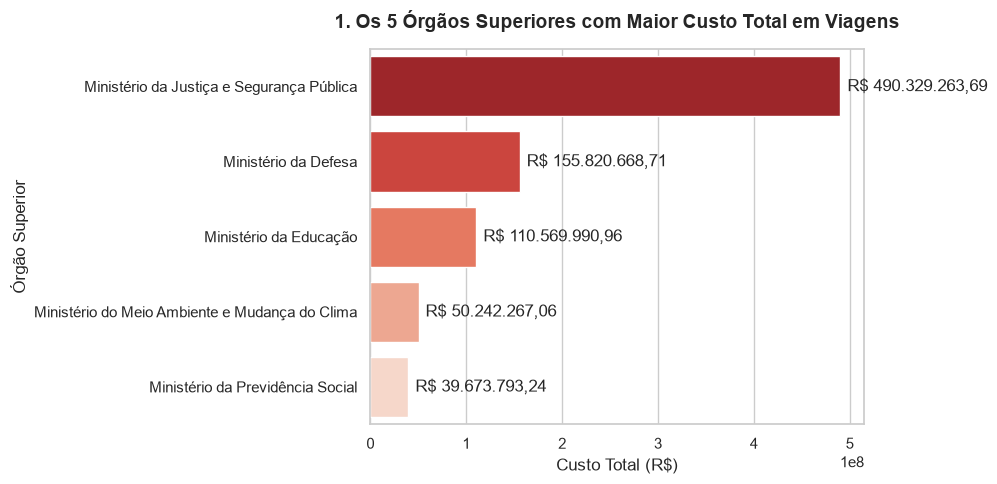

In [9]:
# Pergunta 1: Os 5 órgãos com maior custo total?
conexao = conectar()

query_p1 = """
    SELECT nome_orgao_superior, custo_total_geral
    FROM gold_resumo_orgao
    ORDER BY custo_total_geral DESC
    LIMIT 5;
"""

df_p1 = pd.read_sql_query(query_p1, conexao)
conexao.close()

print("--- 1. Top 5 Órgãos com Maior Custo Total ---")
display(df_p1)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_p1, x="custo_total_geral", y="nome_orgao_superior", hue="nome_orgao_superior", palette="Reds_r", legend=False)
plt.title("1. Os 5 Órgãos Superiores com Maior Custo Total em Viagens", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Custo Total (R$)", fontsize=12)
plt.ylabel("Órgão Superior", fontsize=12)

for container in ax.containers:
    labels = [f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".") for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5)

plt.tight_layout()
plt.show()

### Pergunta 2 - Os 3 Destinos com Maior Custo Médio

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\1764348433.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_p2 = pd.read_sql_query(query_p2, conexao)


--- 2. Top 3 Destinos com Maior Custo Médio por Viagem ---


,destinos,custo_medio_viagem
0,"Abu Dabi/Emirados Árabes, Riad/Arábia Saudita,...",243997.56
1,"Brasília/DF, Rio Branco/AC, Cruzeiro do Sul/AC...",216729.36
2,"Brasília/DF, Rio de Janeiro/RJ, Angra dos Reis...",207220.14


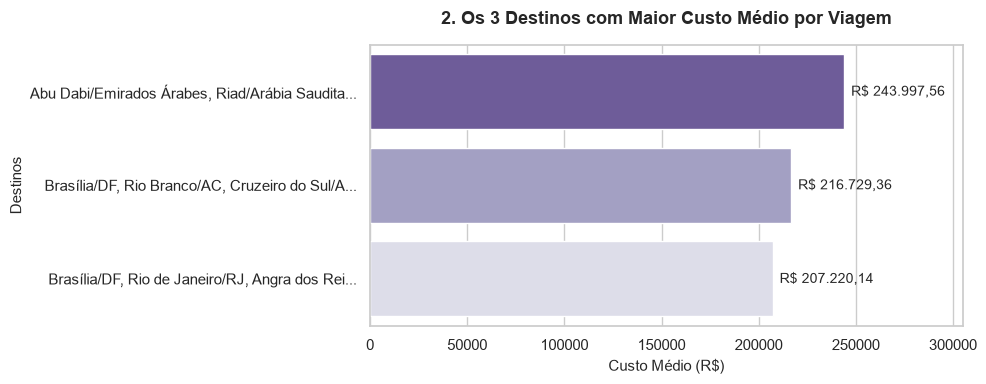

In [8]:
# Pergunta 2: Os 3 destinos com maior custo médio por viagem?
conexao = conectar()

query_p2 = """
    SELECT destinos, AVG(valor_total) AS custo_medio_viagem
    FROM silver_viagem
    WHERE destinos IS NOT NULL AND destinos != 'Sem Informação'
    GROUP BY destinos
    ORDER BY custo_medio_viagem DESC
    LIMIT 3;
"""

df_p2 = pd.read_sql_query(query_p2, conexao)
conexao.close()

# Trunca o texto dos destinos se for muito longo para o gráfico ficar limpo
df_p2['destino_resumido'] = df_p2['destinos'].apply(lambda x: x[:45] + '...' if len(str(x)) > 45 else str(x))

print("--- 2. Top 3 Destinos com Maior Custo Médio por Viagem ---")
display(df_p2[['destinos', 'custo_medio_viagem']])

# Gráfico de Barras Horizontais para lidar melhor com textos longos
plt.figure(figsize=(10, 4))
ax = sns.barplot(
    data=df_p2, 
    x="custo_medio_viagem", 
    y="destino_resumido", 
    hue="destino_resumido", 
    palette="Purples_r", 
    legend=False
)

plt.title("2. Os 3 Destinos com Maior Custo Médio por Viagem", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Custo Médio (R$)", fontsize=11)
plt.ylabel("Destinos", fontsize=11)

# Rótulos de valor formatados no padrão PT-BR
for container in ax.containers:
    labels = [f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".") for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5, fontsize=10)

# Garante margem para o texto não ser cortado
plt.xlim(0, df_p2['custo_medio_viagem'].max() * 1.25)
plt.tight_layout()
plt.show()

### Pergunta 3 - Viagem de Maior Duração

In [6]:
# Pergunta 3: A viagem de maior duração e seu custo total?
conexao = conectar()

query_p3 = """
    SELECT id_viagem, nome_viajante, nome_orgao_superior, duracao_dias, valor_total
    FROM silver_viagem
    ORDER BY duracao_dias DESC, valor_total DESC
    LIMIT 1;
"""

df_p3 = pd.read_sql_query(query_p3, conexao)
conexao.close()

print("--- 3. Viagem de Maior Duração Registrada ---")
display(df_p3)

# Extração e exibição direta das informações
viajante = df_p3['nome_viajante'].values[0]
orgao = df_p3['nome_orgao_superior'].values[0]
duracao = df_p3['duracao_dias'].values[0]
custo = df_p3['valor_total'].values[0]

print("\n" + "=" * 60)
print(f" *** RESPOSTA: ***")
print(f"A viagem de maior duração foi realizada por {viajante} ({orgao}).")
print(f" Duração total: {duracao} dias")
print(f" Custo total: R$ {custo:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print("=" * 60)

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\3558805996.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_p3 = pd.read_sql_query(query_p3, conexao)


--- 3. Viagem de Maior Duração Registrada ---


,id_viagem,nome_viajante,nome_orgao_superior,duracao_dias,valor_total
0,0000000000020699856,LUISANGELA CORREA FRANCO DE FARIA,Ministério da Previdência Social,383,0.0



 *** RESPOSTA: ***
A viagem de maior duração foi realizada por LUISANGELA CORREA FRANCO DE FARIA (Ministério da Previdência Social).
 Duração total: 383 dias
 Custo total: R$ 0,00


### Pergunta 4 - Tipo de Pagamento com Maior Valor Médio

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\2171056312.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_p4 = pd.read_sql_query(query_p4, conexao)


--- 4. Tipo de Pagamento com Maior Valor Médio ---


,tipo_pagamento,valor_medio
0,DIÁRIAS,2078.280299
1,PASSAGEM,1878.344393
2,Serviço correlato: seguro,447.514653
3,RESTITUIÇÃO,245.702610


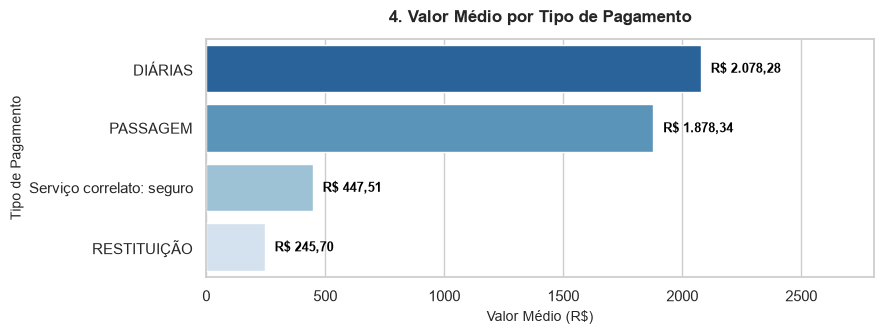

In [12]:
# Pergunta 4: Qual o tipo de pagamento com maior valor médio?
conexao = conectar()

query_p4 = """
    SELECT tipo_pagamento, AVG(valor) AS valor_medio
    FROM silver_pagamento
    GROUP BY tipo_pagamento
    ORDER BY valor_medio DESC;
"""

df_p4 = pd.read_sql_query(query_p4, conexao)
conexao.close()

print("--- 4. Tipo de Pagamento com Maior Valor Médio ---")
display(df_p4)

# Gráfico compacto
fig, ax = plt.subplots(figsize=(9, 3.5))

sns.barplot(
    data=df_p4, 
    x="valor_medio", 
    y="tipo_pagamento", 
    hue="tipo_pagamento", 
    palette="Blues_r", 
    legend=False,
    ax=ax
)

plt.title("4. Valor Médio por Tipo de Pagamento", fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Valor Médio (R$)", fontsize=10)
plt.ylabel("Tipo de Pagamento", fontsize=10)

# Escreve explicitamente o valor ao lado de CADA barra garantindo que nenhum fique de fora
for i, row in df_p4.iterrows():
    valor = row['valor_medio']
    texto_valor = f"R$ {valor:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    # Desenha o texto na coordenada exata (x = valor + offset, y = posição da barra)
    ax.text(
        valor + (df_p4['valor_medio'].max() * 0.02), # pequeno offset à direita
        i, 
        texto_valor, 
        va='center', 
        ha='left', 
        fontsize=9, 
        fontweight='bold', 
        color='black'
    )

# Folga no limite do eixo X para o texto caber folgado
ax.set_xlim(0, df_p4['valor_medio'].max() * 1.35)

plt.tight_layout()
plt.show()

### Pergunta 7 - Órgão Pagador com Maior Custo Total

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11456\1672108090.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_p7 = pd.read_sql_query(query_p7, conexao)


--- 7. Top Órgãos Pagadores com Maior Valor Total ---


,nome_orgao_pagador,total_pago
0,Fundo Nacional de Segurança Pública,2.784810e+08
1,Sigiloso,2.004848e+08
2,Comando da Aeronáutica,8.176914e+07
3,Instituto Nacional do Seguro Social,3.742760e+07
4,Comando do Exército,3.687264e+07


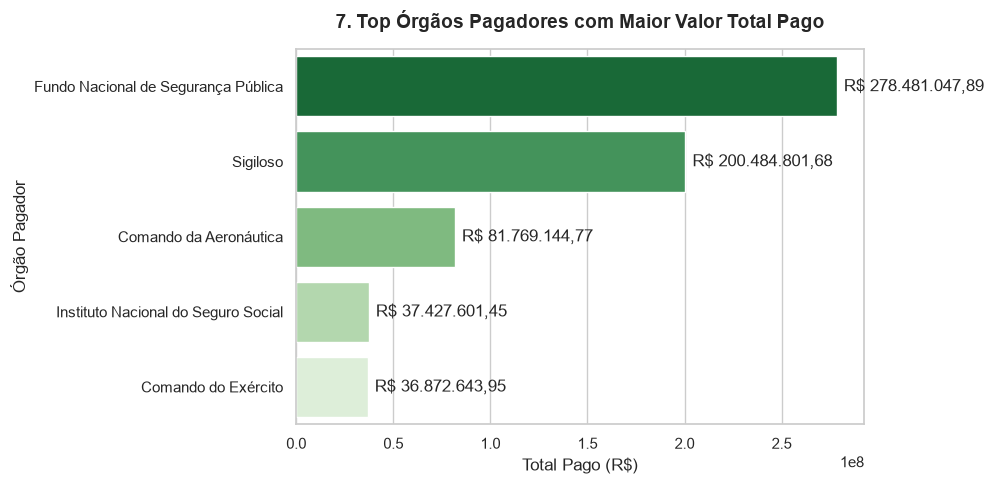

In [13]:
# Pergunta 7: Qual órgão pagou mais no total?
conexao = conectar()

query_p7 = """
    SELECT nome_orgao_pagador, SUM(valor) AS total_pago
    FROM silver_pagamento
    WHERE nome_orgao_pagador IS NOT NULL AND nome_orgao_pagador != ''
    GROUP BY nome_orgao_pagador
    ORDER BY total_pago DESC
    LIMIT 5;
"""

df_p7 = pd.read_sql_query(query_p7, conexao)
conexao.close()

print("--- 7. Top Órgãos Pagadores com Maior Valor Total ---")
display(df_p7)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=df_p7, x="total_pago", y="nome_orgao_pagador", hue="nome_orgao_pagador", palette="Greens_r", legend=False)
plt.title("7. Top Órgãos Pagadores com Maior Valor Total Pago", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Total Pago (R$)", fontsize=12)
plt.ylabel("Órgão Pagador", fontsize=12)

for container in ax.containers:
    labels = [f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".") for v in container.datavalues]
    ax.bar_label(container, labels=labels, padding=5)

plt.tight_layout()
plt.show()